In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from google.cloud import bigquery

pd.set_option('display.max_rows', None)
sns.set_style('darkgrid')


# Conexao inicial com Bigquery

In [2]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=KW5BGWVXj5IxyBn36vqZ3Jkuzfc2OF&access_type=offline&code_challenge=pVNK3ELuCKzwOEn-_Wjfb8T52v4R25pR7UH3tY8nQiM&code_challenge_method=S256


Credentials saved to file: [C:\Users\pedro\AppData\Roaming\gcloud\application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "groova-pml-20261" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


In [3]:
# extraindo 100 registros para explorar
client = bigquery.Client(project='groova-pml-20261',
                         location='southamerica-east1')

query = """
SELECT
    f.*,
    r.nota,
    r.valor_oferta
FROM `groova-pml-20261.groova_features.groova_features_1000` f
LEFT JOIN `groova-pml-20261.groova_base_full.groova_dataset_raw` r
ON f.artist_key = r.artist_key
LIMIT 100;

"""

df = client.query(query).to_dataframe()

C:\Users\pedro\miniconda3\envs\project_ml\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


# Exploração Inicial

## Esquemas e Tipos

In [4]:
df.head()

,artist_key,artist_name,ID_ARTISTA,estilo,formacao,cidade,uf,video_url,video_title,video_channel,...,chroma_07_mean,chroma_08_mean,chroma_09_mean,chroma_10_mean,chroma_11_mean,chroma_12_mean,onset_strength_mean,onset_strength_std,nota,valor_oferta
0,renatinho,RENATINHO,21275,Pagode,Banda,Angra dos Reis,RJ,https://youtu.be/VTpmMDhwMQs?si=ZuZYOmFmidX0qQXv,RENATINHO - Mix Pixote (ao vivo),RENATINHO,...,0.199709,0.253398,0.406464,0.584068,0.682011,0.540337,1.202674,0.574575,10.8333,3850.0
1,banda rockflash,Banda Rockflash,17933,Rock,Banda,Anápolis,GO,https://youtu.be/wT42ibySu0I?si=IPYisMdc_7nB9yLx,Banda RockFlash tocando músicas Rock e Flashba...,Banda RockFlash,...,0.346221,0.390364,0.441613,0.340369,0.428493,0.406266,1.325430,1.278610,10.8333,200.0
2,luiz gusttavo,Luiz Gusttavo,2573,Sertanejo,Banda,Aparecida de Goiânia,GO,https://youtu.be/GxMvvIiFIHU,Luiz Gusttavo - A Casa Caiu,Luiz Gusttavo,...,0.387655,0.316887,0.448131,0.338034,0.430827,0.398413,1.649553,1.743359,10.8333,2500.0
3,para tudo,Para tudo,21810,Pagode,Banda,Barueri,SP,https://youtu.be/YLPnZp80uP8?si=MboJfEjl5BxTtQdu,PARATUDO - Novas Regras (Videoclipe Oficial),Para Tudo Oficial,...,0.428439,0.308621,0.308687,0.292262,0.227682,0.307357,1.676373,1.830143,1.6944,1700.0
4,raiz samba drums,Raiz Samba Drums,16902,Samba,Banda,Belo Horizonte,MG,https://youtu.be/gGkAW48-1Qw?si=HFcFWPGCDg2klI39,"Raiz Samba Drums , Pé na Areia .",Patrick Constantino,...,0.275002,0.395585,0.387866,0.383843,0.369966,0.358907,1.720523,2.262120,12.6088,600.0


In [7]:
# observando os dados
print('- TAMANHO DOS DADOS')
print(f'tamanho do dataset: {df.shape[0]}')
print(f'quantidade de features: {df.shape[1]}')
print('='*50)
print('- INDENTIFICACAO DOS ARTISTAS')
print(f'quantidade de Artistas: {df.ID_ARTISTA.nunique()}')
print(f'quantidade de Estilos: {df.estilo.nunique()}')
print(f'tipos de formacao de banda: {df.formacao.unique()}')
print(f'quantidade de cidades: {df.cidade.nunique()}')
print(f'estados: Total {df.uf.nunique()} - {df.uf.unique()} ')
print('='*50)
print('- AVALIACOES DOS ARTISTAS')
print(f'range das notas: {df.nota.min()} - {df.nota.max()}')
print(f'range dos valores de oferta: {df.valor_oferta.min()} - {df.valor_oferta.max()}')

print('='*50)
print('- DADOS NUMERICOS SOBRE OS AUDIOS')
data_audio = ['video_duration_sec', 'audio_total_duration_sec', 'segment_n_used', 'segment_duration_sec', 'feature_sampling_mode', 'tempo_bpm', 'rms_mean', 'rms_std', 'zcr_mean', 'zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_flatness_mean', 'spectral_flatness_std', 'onset_strength_mean', 'onset_strength_std', 'mfcc_01_mean', 'mfcc_02_mean', 'mfcc_03_mean', 'mfcc_04_mean', 'mfcc_05_mean', 'mfcc_06_mean', 'mfcc_07_mean', 'mfcc_08_mean', 'mfcc_09_mean', 'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_13_mean', 'chroma_01_mean', 'chroma_02_mean', 'chroma_03_mean', 'chroma_04_mean', 'chroma_05_mean', 'chroma_06_mean', 'chroma_07_mean', 'chroma_08_mean', 'chroma_09_mean', 'chroma_10_mean', 'chroma_11_mean', 'chroma_12_mean']
print(f'colunas: {data_audio}')



- TAMANHO DOS DADOS
tamanho do dataset: 100
quantidade de features: 57
- INDENTIFICACAO DOS ARTISTAS
quantidade de Artistas: 100
quantidade de Estilos: 18
tipos de formacao de banda: ['Banda']
quantidade de cidades: 26
estados: Total 11 - ['RJ' 'GO' 'SP' 'MG' 'DF' 'MS' 'MT' 'PR' 'SC' 'CE' 'BA'] 
- AVALIACOES DOS ARTISTAS
range das notas: 1.6667 - 13.7119
range dos valores de oferta: 0.0 - 7000.0
- DADOS NUMERICOS SOBRE OS AUDIOS
colunas: ['video_duration_sec', 'audio_total_duration_sec', 'segment_n_used', 'segment_duration_sec', 'feature_sampling_mode', 'tempo_bpm', 'rms_mean', 'rms_std', 'zcr_mean', 'zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_flatness_mean', 'spectral_flatness_std', 'onset_strength_mean', 'onset_strength_std', 'mfcc_01_mean', 'mfcc_02_mean', 'mfcc_03_mean', 'mfcc_04_mean', 'mfcc_05_mean', 'mfcc_06_mean', 'mfcc_07_mean', 'mfcc_08_mean', 'mfc

## Explicações sobre as Features dos Audios

### Features de metadados do áudio:
**video_duration_sec** — duração total do vídeo em segundos.

**audio_total_duration_sec** — duração total do áudio extraído, em segundos.

**segment_n_used** — quantidade de segmentos do áudio que foram usados para extrair as features (provavelmente o áudio foi dividido em trechos).

**segment_duration_sec** — duração de cada segmento em segundos.

**feature_sampling_mode** — método usado para amostrar/agregar as features dos segmentos (ex: média, mediana, etc.).

### Features temporais / rítmicas:
**tempo_bpm** — estimativa do andamento da música em batidas por minuto. Valores mais altos indicam músicas mais rápidas.

**onset_strength_mean / _std** — mede a intensidade dos "ataques" sonoros, ou seja, o quão marcadas são as transições de silêncio para som (ou de um som para outro). Está diretamente relacionado à percussividade: bateria forte e ataques de guitarra geram onset strength alto. A média (mean) indica o nível geral de percussividade, e o desvio padrão (std) indica o quanto essa percussividade varia ao longo do tempo.

### Features de energia e cruzamento por zero:
**rms_mean / _std** — Root Mean Square. Mede a energia do sinal. Quanto maior o RMS, mais alto/potente o som. A média reflete o volume geral da faixa, e o std indica variação dinâmica (uma música com muitas partes suaves e altas terá std alto).

**zcr_mean / _std** — Zero Crossing Rate, a taxa com que o sinal cruza o eixo zero (muda de positivo para negativo). Mede ruidosidade e "textura" do som. Sons mais agudos e ruidosos têm ZCR alto; sons graves e tonais têm ZCR baixo.

### Features espectrais:
**spectral_centroid_mean / _std** — o "centro de massa" do espectro de frequências. Indica brilho percebido: valores altos = som agudo/brilhante; valores baixos = som grave/escuro.

**spectral_bandwidth_mean / _std** — largura da dispersão das frequências ao redor do centroide. Bandwidth alto = som cheio/complexo; bandwidth baixo = som puro/tonal.

**spectral_rolloff_mean / _std** — frequência abaixo da qual uma porcentagem da energia do espectro está concentrada (85% por padrão). Indica até onde a energia do som se estende.

**spectral_flatness_mean / _std** — mede quão uniforme é o espectro (0 a 1). Valor próximo de 1 = ruído; próximo de 0 = som tonal.

### MFCCs (Mel-Frequency Cepstral Coefficients):
**mfcc_01_mean a mfcc_13_mean** — coeficientes que comprimem o espectro geral do som em menos valores, descrevendo o contorno geral do espectro. Capturam o timbre do áudio.
- **MFCC 1**: energia geral / loudness.
- **MFCCs 2-3**: inclinação do espectro (grave vs. agudo).
- **MFCCs 4-13**: detalhes finos do espectro (harmônicos, ressonâncias).

### Chroma features:
**chroma_01_mean a chroma_12_mean** — capturam características harmônicas e melódicas da música. Cada valor corresponde a uma das 12 notas da escala cromática ocidental (Dó, Dó#, Ré, Ré#, Mi, Fá, Fá#, Sol, Sol#, Lá, Lá#, Si).
Codificam a distribuição de energia sobre as doze bandas de chroma. Úteis para identificar tonalidades, progressões harmônicas e assinaturas musicais.

# Qualidade dos Dados

In [9]:
df.isnull().sum()

artist_key                 0
artist_name                0
ID_ARTISTA                 0
estilo                     0
formacao                   0
cidade                     0
uf                         0
video_url                  0
video_title                0
video_channel              0
video_duration_sec         0
segment_start_sec          0
segment_duration_sec       0
duration_sec               0
sample_rate                0
tempo_bpm                  0
rms_mean                   0
rms_std                    0
zcr_mean                   0
zcr_std                    0
spectral_centroid_mean     0
spectral_centroid_std      0
spectral_bandwidth_mean    0
spectral_bandwidth_std     0
spectral_rolloff_mean      0
spectral_rolloff_std       0
spectral_flatness_mean     0
spectral_flatness_std      0
mfcc_01_mean               0
mfcc_02_mean               0
mfcc_03_mean               0
mfcc_04_mean               0
mfcc_05_mean               0
mfcc_06_mean               0
mfcc_07_mean  

In [32]:
# verificando ids duplicados
duplicatas = df.duplicated('artist_key').value_counts().to_frame()
print(duplicatas)

       count
False    100


In [11]:
# verificando valor nulo em valor_oferta
df.loc[ df.valor_oferta.isnull() ]

,artist_key,artist_name,ID_ARTISTA,estilo,formacao,cidade,uf,video_url,video_title,video_channel,...,chroma_07_mean,chroma_08_mean,chroma_09_mean,chroma_10_mean,chroma_11_mean,chroma_12_mean,onset_strength_mean,onset_strength_std,nota,valor_oferta
21,grupo vida samba,Grupo vida samba,17388,Pagode,Banda,Campinas,SP,https://youtu.be/Q_UL1u-HyQw?si=zjTXa7hTHxu0V6mL,Grupo Vida Samba - NOSSA VIDA É SAMBA - (Ao Vi...,grupovidasambaoficial,...,0.308331,0.46151,0.379094,0.329365,0.305642,0.357373,1.813631,1.839208,12.6517,NaN


In [33]:
# removendo features completamente nulas caso exista
len_dataset = len(df)
contagens_nulo = df.isnull().sum()

colunas_dropada = 0
nome_colunas_dropadas = []
for coluna, valor in contagens_nulo.items():
    if valor == len_dataset:
        df = df.drop(columns=[coluna])
        colunas_dropada += 1
        nome_colunas_dropadas.append(coluna)

print(f'Quantidade de colunas dropadas: {colunas_dropada}')
print(f'Nome de colunas dropadas: {nome_colunas_dropadas}')


Quantidade de colunas dropadas: 0
Nome de colunas dropadas: []


# EAD

## Variaveis Categorigas

In [34]:
col_categoricas = df.select_dtypes('object')
col_categoricas = col_categoricas.drop(columns=['artist_key','artist_name','video_url','video_title','video_channel'])
col_categoricas.head()

,estilo,formacao,cidade,uf
0,Pagode,Banda,Angra dos Reis,RJ
1,Rock,Banda,Anápolis,GO
2,Sertanejo,Banda,Aparecida de Goiânia,GO
3,Pagode,Banda,Barueri,SP
4,Samba,Banda,Belo Horizonte,MG


Tipo de formaçao de banda
Apenas existe um unico tipo: ['Banda']


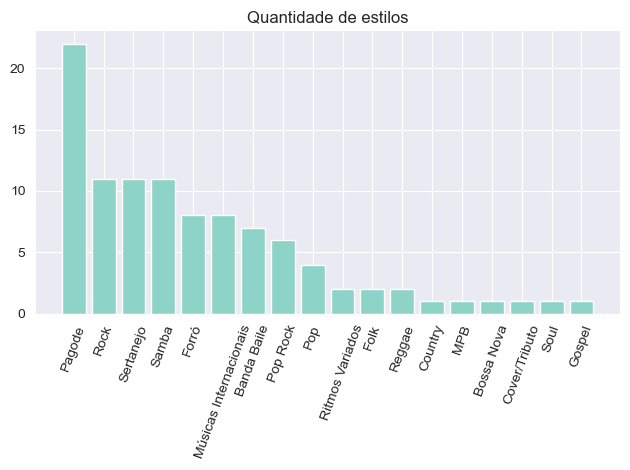

In [37]:
# frequencia de estilos
print('Tipo de formaçao de banda')
print(f'Apenas existe um unico tipo: {col_categoricas.formacao.unique()}')
plt.bar(col_categoricas.estilo.unique(), col_categoricas.estilo.value_counts())
plt.xticks(rotation=70)
plt.title('Quantidade de estilos')

plt.tight_layout()
plt.show()


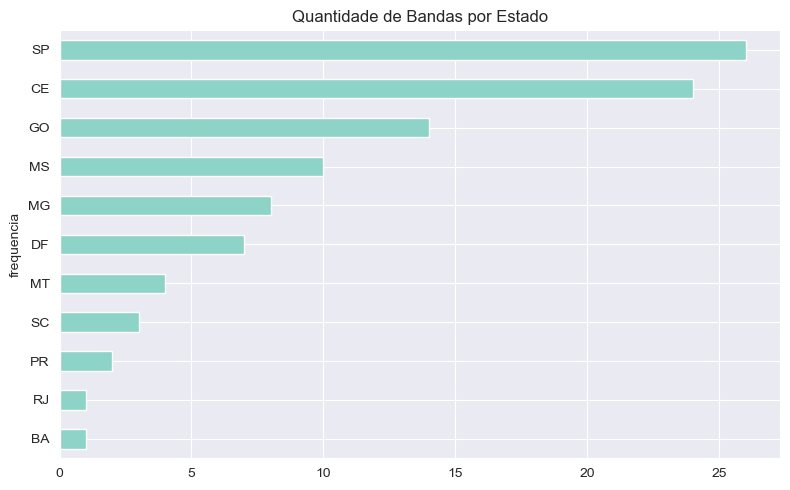

In [93]:
# quais sao os estados que aprenseta o maior numero de bandas ?
est_banda = df.groupby('uf')['formacao'].count().sort_values(ascending=True)
plt.figure(figsize=(8,5))
est_banda.plot.barh()
plt.title('Quantidade de Bandas por Estado')
plt.ylabel('frequencia')
plt.tight_layout()
plt.show()


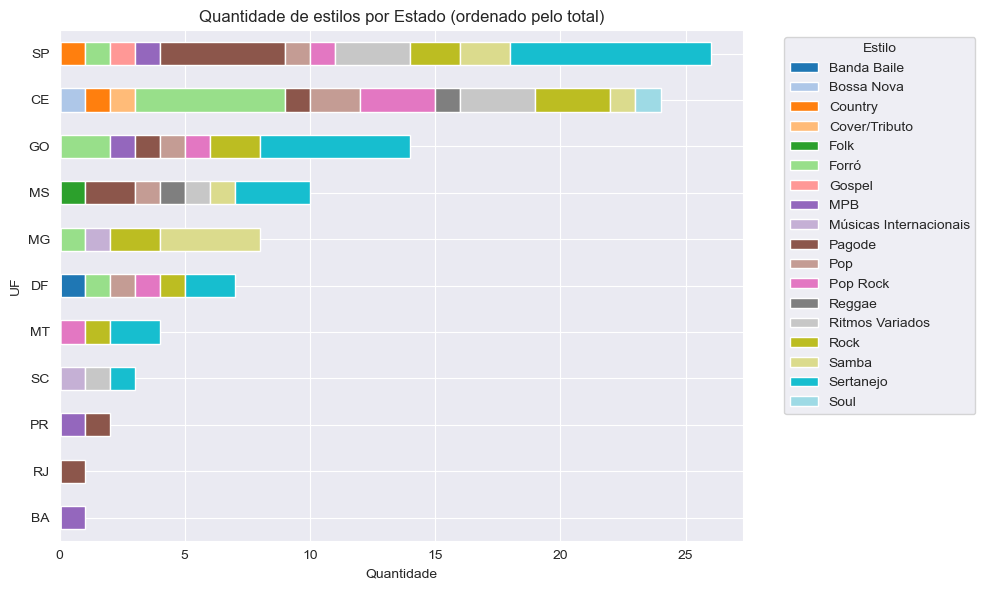

In [82]:
est_estilo = (
    df.groupby(['uf','estilo'])
      .size()
      .unstack(fill_value=0)
)
est_estilo['Total'] = est_estilo.sum(axis=1)
est_estilo = est_estilo.sort_values(by='Total', ascending=True)

est_estilo.drop(columns='Total').plot(
    kind='barh', stacked=True, figsize=(10,6), colormap='tab20'
)
plt.title("Quantidade de estilos por Estado (ordenado pelo total)")
plt.xlabel("Quantidade")
plt.ylabel("UF")
plt.legend(title="Estilo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Variaveis Numericas

In [64]:
col_num = df.select_dtypes('number')
col_num = col_num.drop(columns=['ID_ARTISTA','video_duration_sec','segment_start_sec','segment_duration_sec','duration_sec'])
col_num.head()

,sample_rate,tempo_bpm,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,...,chroma_07_mean,chroma_08_mean,chroma_09_mean,chroma_10_mean,chroma_11_mean,chroma_12_mean,onset_strength_mean,onset_strength_std,nota,valor_oferta
0,22050,117.453835,0.265337,0.045628,0.188087,0.098191,4211.603427,782.559904,3760.985894,137.401857,...,0.199709,0.253398,0.406464,0.584068,0.682011,0.540337,1.202674,0.574575,10.8333,3850.0
1,22050,107.666016,0.141949,0.046846,0.056405,0.021639,1454.330967,469.134745,1946.059299,503.152055,...,0.346221,0.390364,0.441613,0.340369,0.428493,0.406266,1.325430,1.278610,10.8333,200.0
2,22050,129.199219,0.259859,0.077548,0.065173,0.026125,2001.579431,640.362935,2517.511353,446.485999,...,0.387655,0.316887,0.448131,0.338034,0.430827,0.398413,1.649553,1.743359,10.8333,2500.0
3,22050,161.499023,0.220882,0.069874,0.090937,0.066795,2711.833037,999.634256,3077.334108,352.156420,...,0.428439,0.308621,0.308687,0.292262,0.227682,0.307357,1.676373,1.830143,1.6944,1700.0
4,22050,99.384014,0.229371,0.058682,0.040081,0.015098,1209.362226,362.692052,1703.543724,311.187219,...,0.275002,0.395585,0.387866,0.383843,0.369966,0.358907,1.720523,2.262120,12.6088,600.0


In [63]:
col_num.describe()

,video_duration_sec,segment_start_sec,segment_duration_sec,duration_sec,sample_rate,tempo_bpm,rms_mean,rms_std,zcr_mean,zcr_std,...,chroma_07_mean,chroma_08_mean,chroma_09_mean,chroma_10_mean,chroma_11_mean,chroma_12_mean,onset_strength_mean,onset_strength_std,nota,valor_oferta
count,100.0,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.000000
mean,793.11,523.307500,10.0,14.390777,22050.0,123.241634,0.217376,0.065080,0.097438,0.046647,...,0.363987,0.381551,0.378464,0.393023,0.354481,0.376619,1.478721,1.475029,10.635206,1197.191919
std,1956.382613,1596.507693,0.0,3.041171,0.0,25.728968,0.081282,0.027694,0.048118,0.021420,...,0.104874,0.114267,0.103972,0.116530,0.098614,0.104164,0.258118,0.530910,3.453328,1229.438587
min,49.0,0.000000,10.0,9.993515,22050.0,64.599609,0.017148,0.019025,0.040081,0.014079,...,0.157218,0.154426,0.126651,0.201514,0.163214,0.180704,0.970948,0.489267,1.666700,0.000000
25%,159.5,46.240000,10.0,11.648515,22050.0,103.359375,0.159925,0.046556,0.072424,0.032084,...,0.287466,0.312366,0.304667,0.320099,0.283474,0.306002,1.305111,1.130785,10.833300,300.000000
50%,193.5,89.130000,10.0,13.973515,22050.0,120.250355,0.218278,0.062965,0.089189,0.042094,...,0.360514,0.373159,0.373741,0.370291,0.329976,0.363871,1.454929,1.494297,12.500000,1000.000000
75%,274.25,163.570000,10.0,16.923515,22050.0,143.554688,0.268075,0.078457,0.104695,0.054960,...,0.429481,0.433512,0.434917,0.432480,0.418361,0.451519,1.677642,1.767096,12.512025,1500.000000
max,10543.0,9668.990000,10.0,19.873515,22050.0,198.768029,0.423669,0.207106,0.431723,0.134457,...,0.743555,0.794124,0.660745,0.809558,0.682011,0.675033,2.370321,3.760833,13.711900,7000.000000


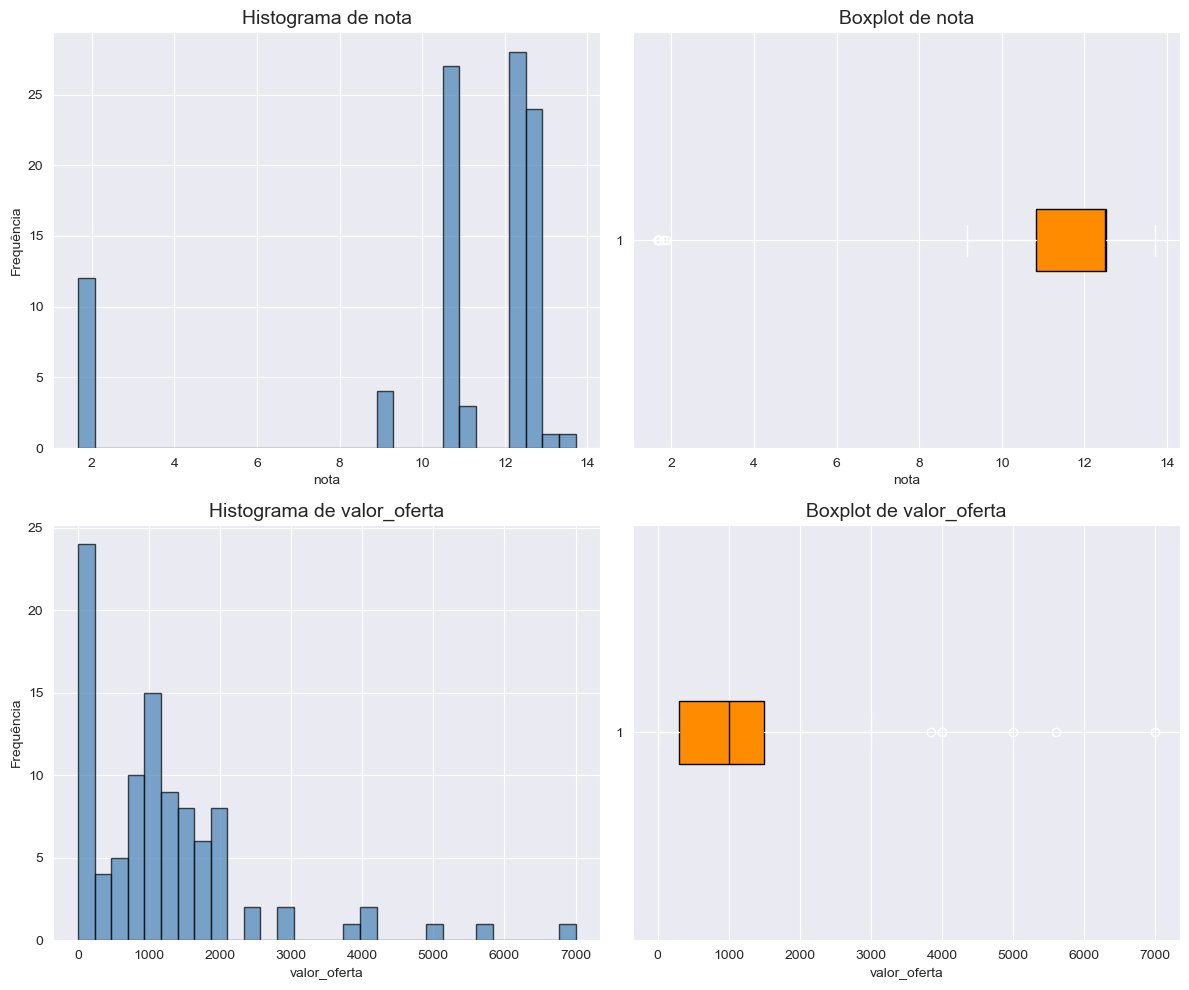

In [70]:
# distribuicao tempo_bpm
cols = ['nota', 'valor_oferta']
fig, axes = plt.subplots(len(cols), 2, figsize=(12, 5*len(cols)))

for i, col in enumerate(cols):
    # Histograma
    axes[i,0].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i,0].set_title(f"Histograma de {col}", fontsize=14)
    axes[i,0].set_xlabel(col)
    axes[i,0].set_ylabel("Frequência")

    # Boxplot
    axes[i,1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                      boxprops=dict(facecolor='darkorange', color='black'),
                      medianprops=dict(color='black'))
    axes[i,1].set_title(f"Boxplot de {col}", fontsize=14)
    axes[i,1].set_xlabel(col)

plt.tight_layout()
plt.show()



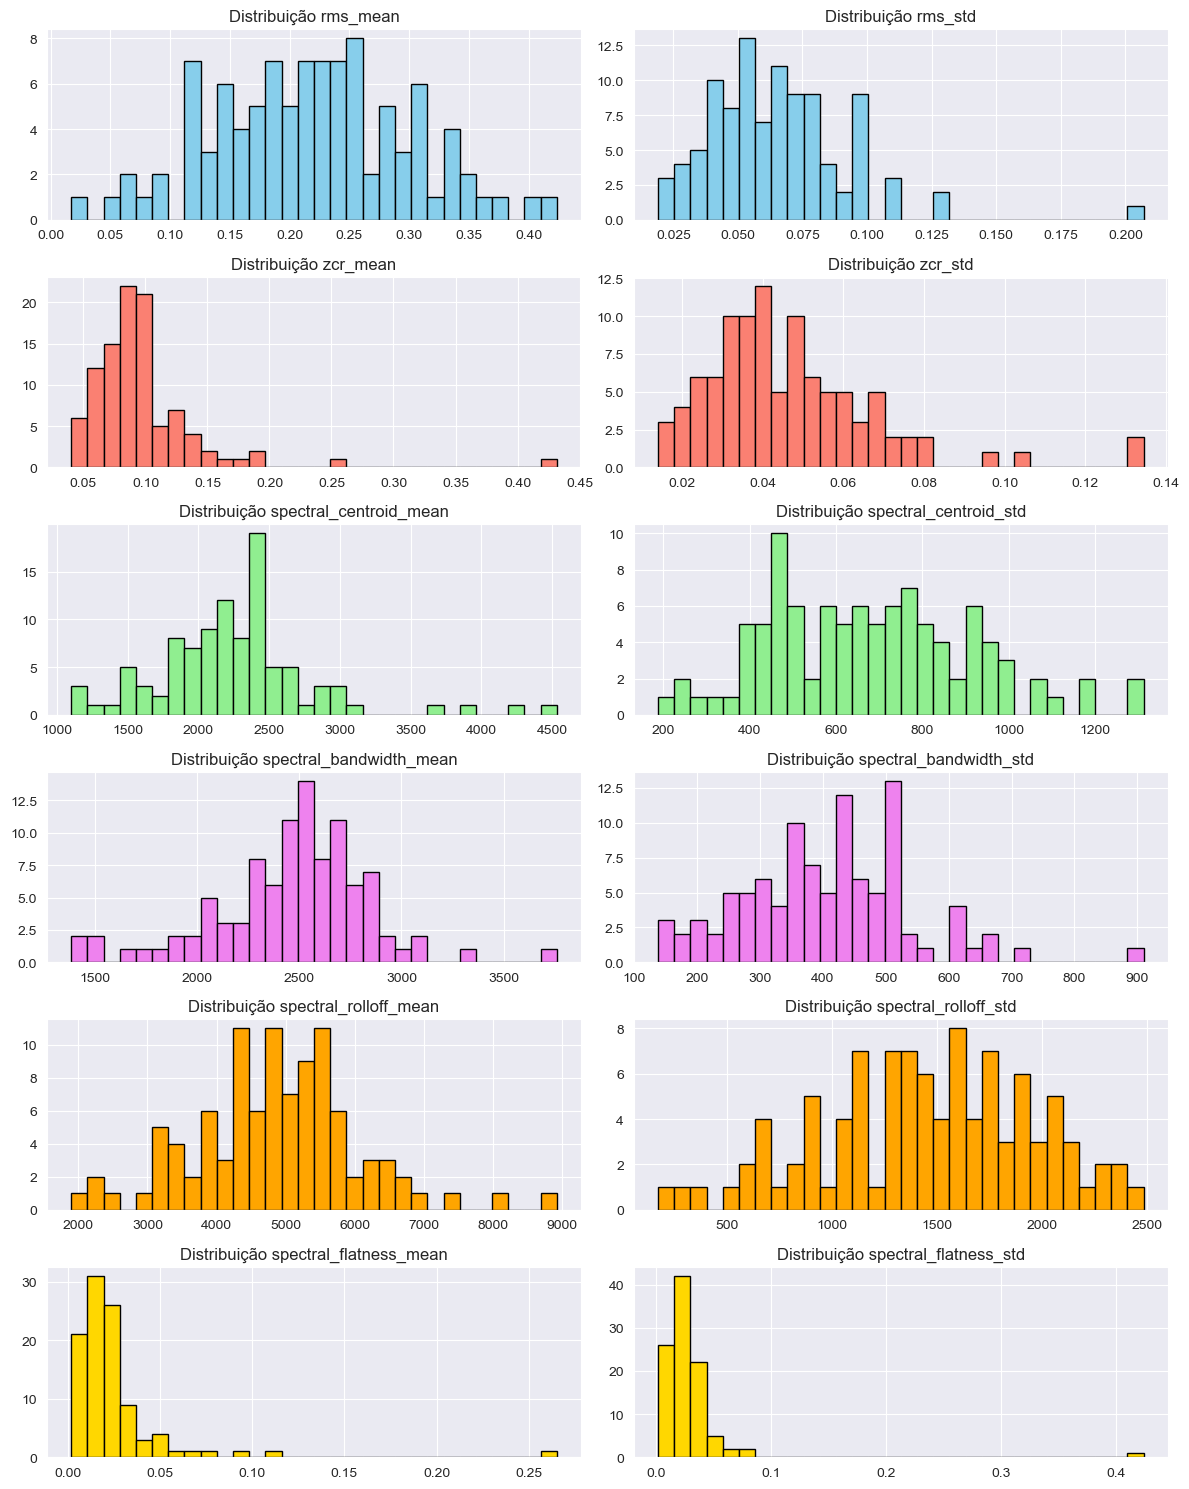

In [55]:
# distribuicao metricas rms, zcr, spectral centroid, spectral brandwidth, spectral flatness
cols = [
    'rms_mean', 'rms_std',
    'zcr_mean', 'zcr_std',
    'spectral_centroid_mean', 'spectral_centroid_std',
    'spectral_bandwidth_mean', 'spectral_bandwidth_std',
    'spectral_rolloff_mean', 'spectral_rolloff_std',
    'spectral_flatness_mean', 'spectral_flatness_std'
]

# Definindo cores para cada par de métricas
colors = {
    'rms': 'skyblue',
    'zcr': 'salmon',
    'spectral_centroid': 'lightgreen',
    'spectral_bandwidth': 'violet',
    'spectral_rolloff': 'orange',
    'spectral_flatness': 'gold'
}

fig, axs = plt.subplots(6, 2, figsize=(12, 15))

for ax, col in zip(axs.flatten(), cols):
    # pega o prefixo antes do último "_"
    prefix = "_".join(col.split("_")[:-1])
    color = colors.get(prefix, 'steelblue')

    ax.hist(df[col], bins=30, color=color, edgecolor='black')
    ax.set_title(f'Distribuição {col}')

plt.tight_layout()
plt.show()

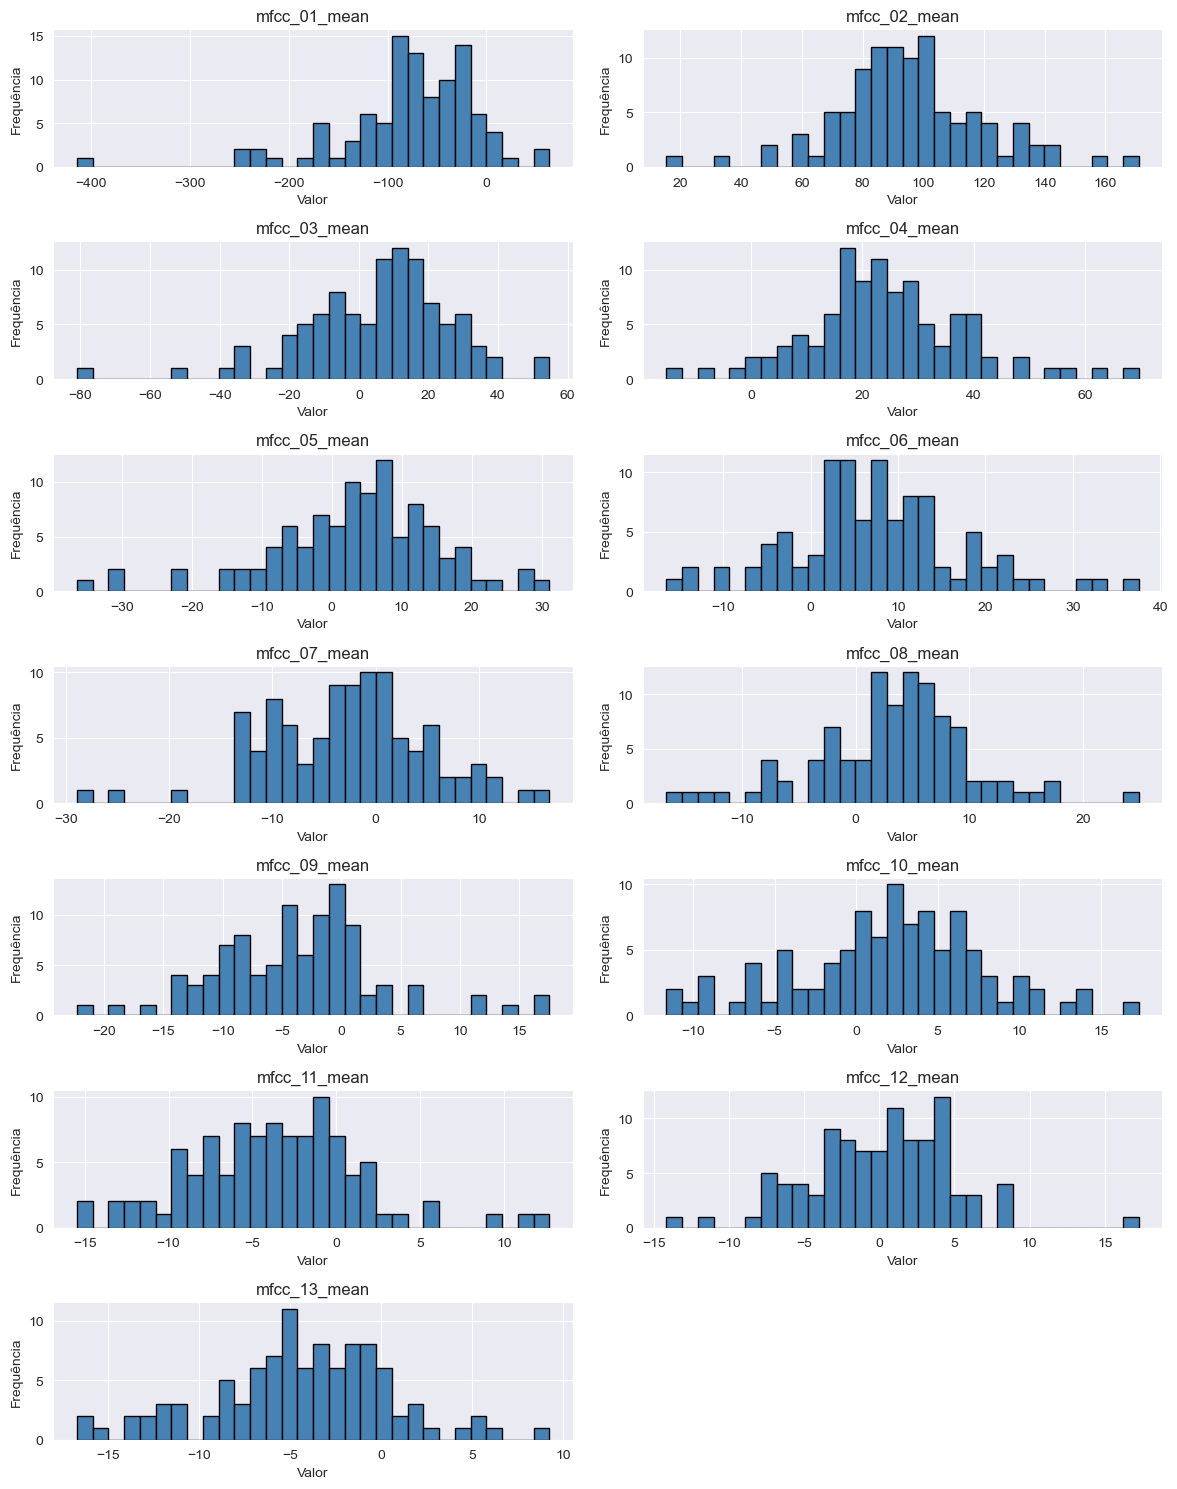

In [47]:
# grafico mfcc

cols_mfcc  = [
    'mfcc_01_mean',
    'mfcc_02_mean', 'mfcc_03_mean', 'mfcc_04_mean', 'mfcc_05_mean',
    'mfcc_06_mean', 'mfcc_07_mean', 'mfcc_08_mean', 'mfcc_09_mean',
    'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_13_mean'
]

fig , ax = plt.subplots(7,2, figsize=(12, 15))
ax = ax.flatten()  # transforma em array 1D para facilitar o loop

for i, col in enumerate(cols_mfcc):
    ax[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    ax[i].set_title(col)
    ax[i].set_xlabel('Valor')
    ax[i].set_ylabel('Frequência')

# remove os subplots extras (porque temos 12 espaços mas só 13 colunas)
for j in range(len(cols_mfcc), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()




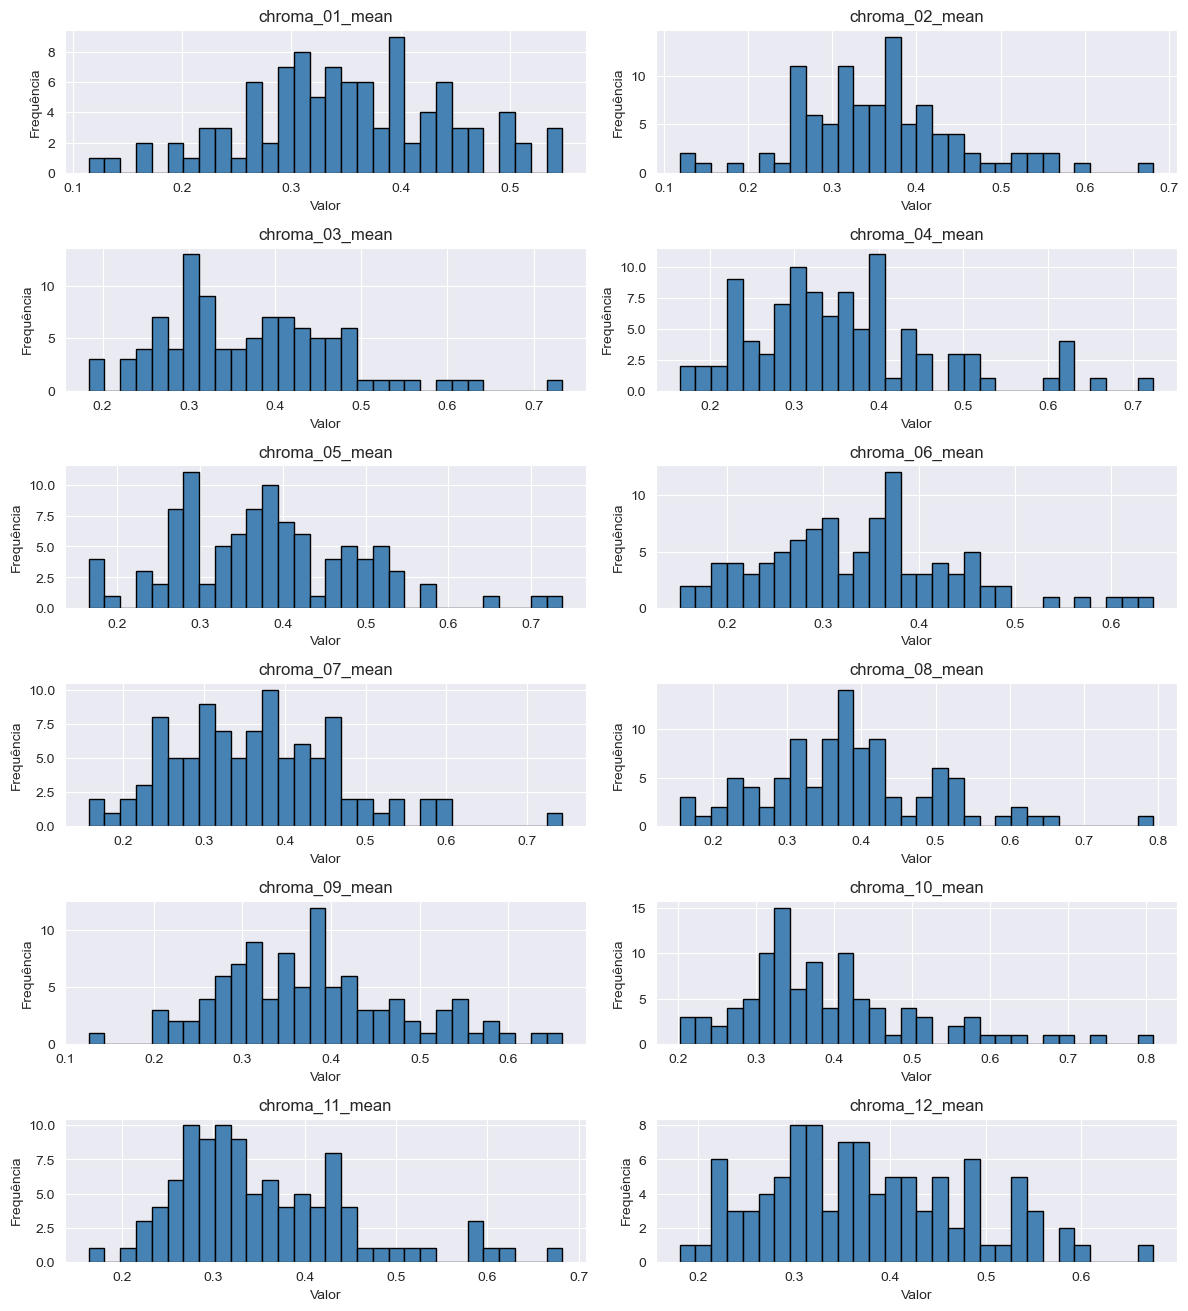

In [49]:
cols_chroma    = [
    'chroma_01_mean', 'chroma_02_mean', 'chroma_03_mean', 'chroma_04_mean',
    'chroma_05_mean', 'chroma_06_mean', 'chroma_07_mean', 'chroma_08_mean',
    'chroma_09_mean', 'chroma_10_mean', 'chroma_11_mean', 'chroma_12_mean',
]

fig , ax = plt.subplots(7,2, figsize=(12, 15))
ax = ax.flatten()  # transforma em array 1D para facilitar o loop

for i, col in enumerate(cols_chroma):
    ax[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    ax[i].set_title(col)
    ax[i].set_xlabel('Valor')
    ax[i].set_ylabel('Frequência')

# remove os subplots extras (porque temos 12 espaços mas só 13 colunas)
for j in range(len(cols_chroma), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

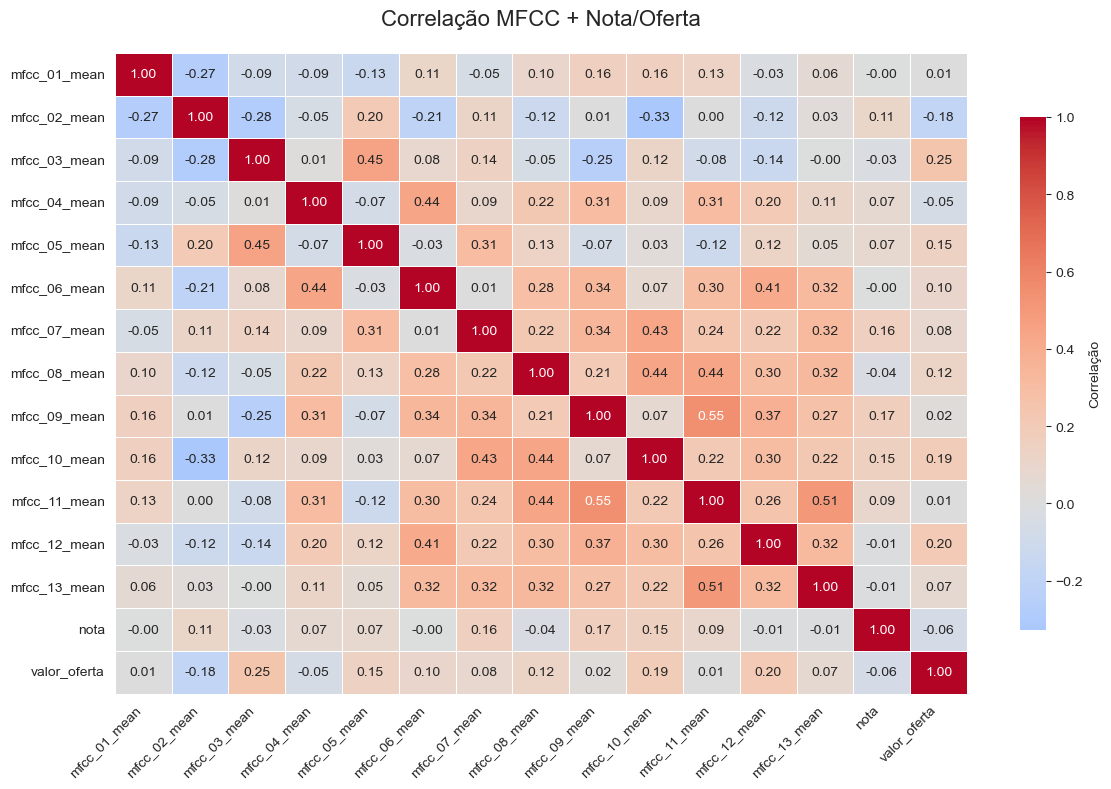

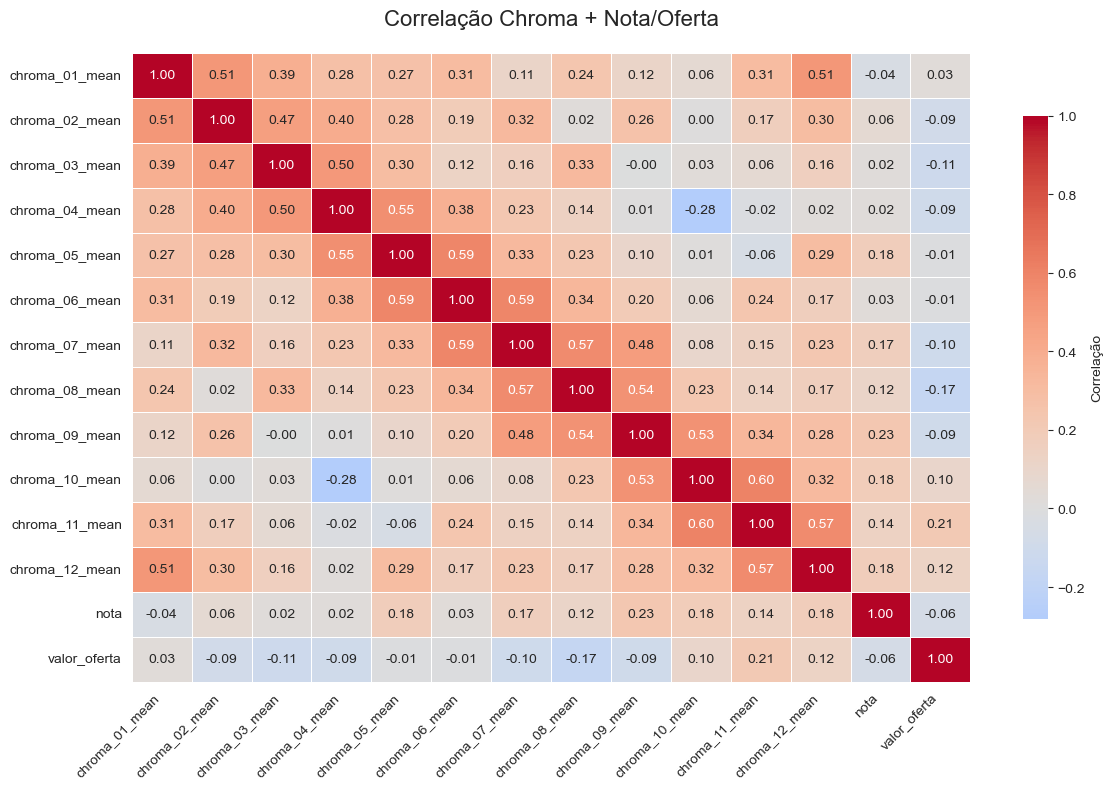

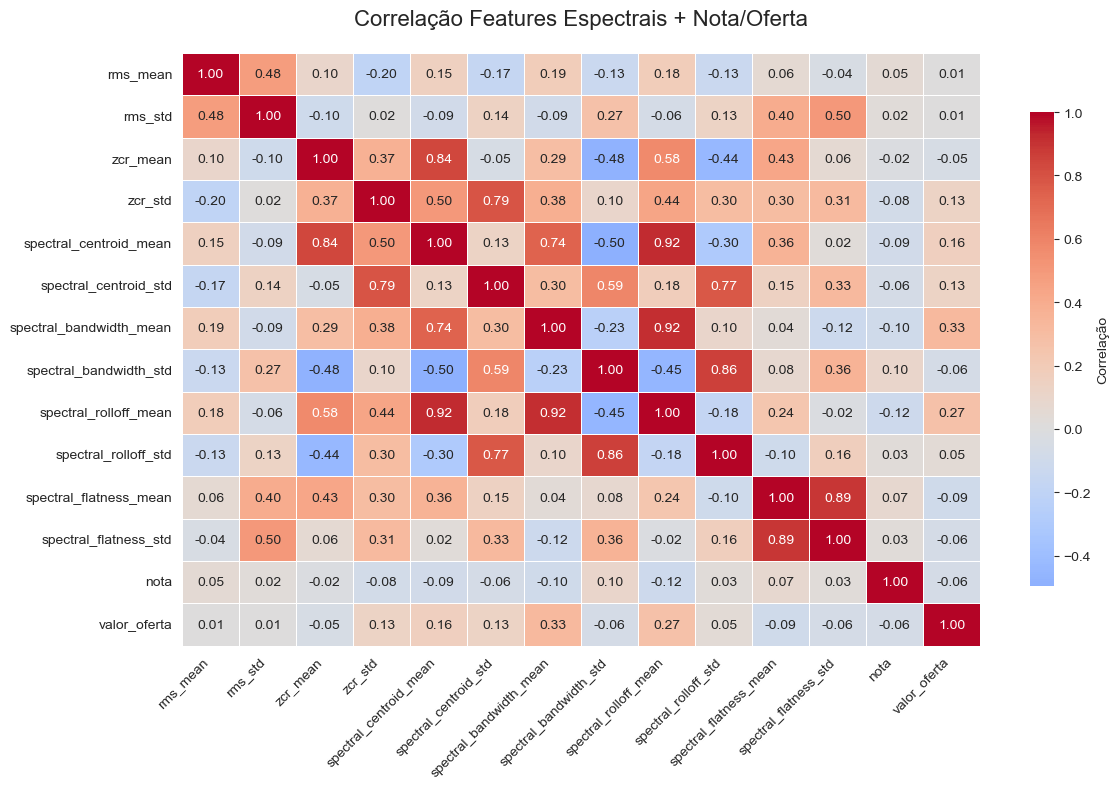

In [56]:
targets = ['nota','valor_oferta']

# Função para plotar heatmap
def plot_corr(df, columns, title):
    corr = df[columns + targets].corr()
    plt.figure(figsize=(12,8))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar_kws={"shrink":0.8,"label":"Correlação"}
    )
    plt.title(title, fontsize=16, pad=20)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Chamadas para cada grupo
plot_corr(df, cols_mfcc, "Correlação MFCC + Nota/Oferta")
plot_corr(df, cols_chroma, "Correlação Chroma + Nota/Oferta")
plot_corr(df, cols, "Correlação Features Espectrais + Nota/Oferta")


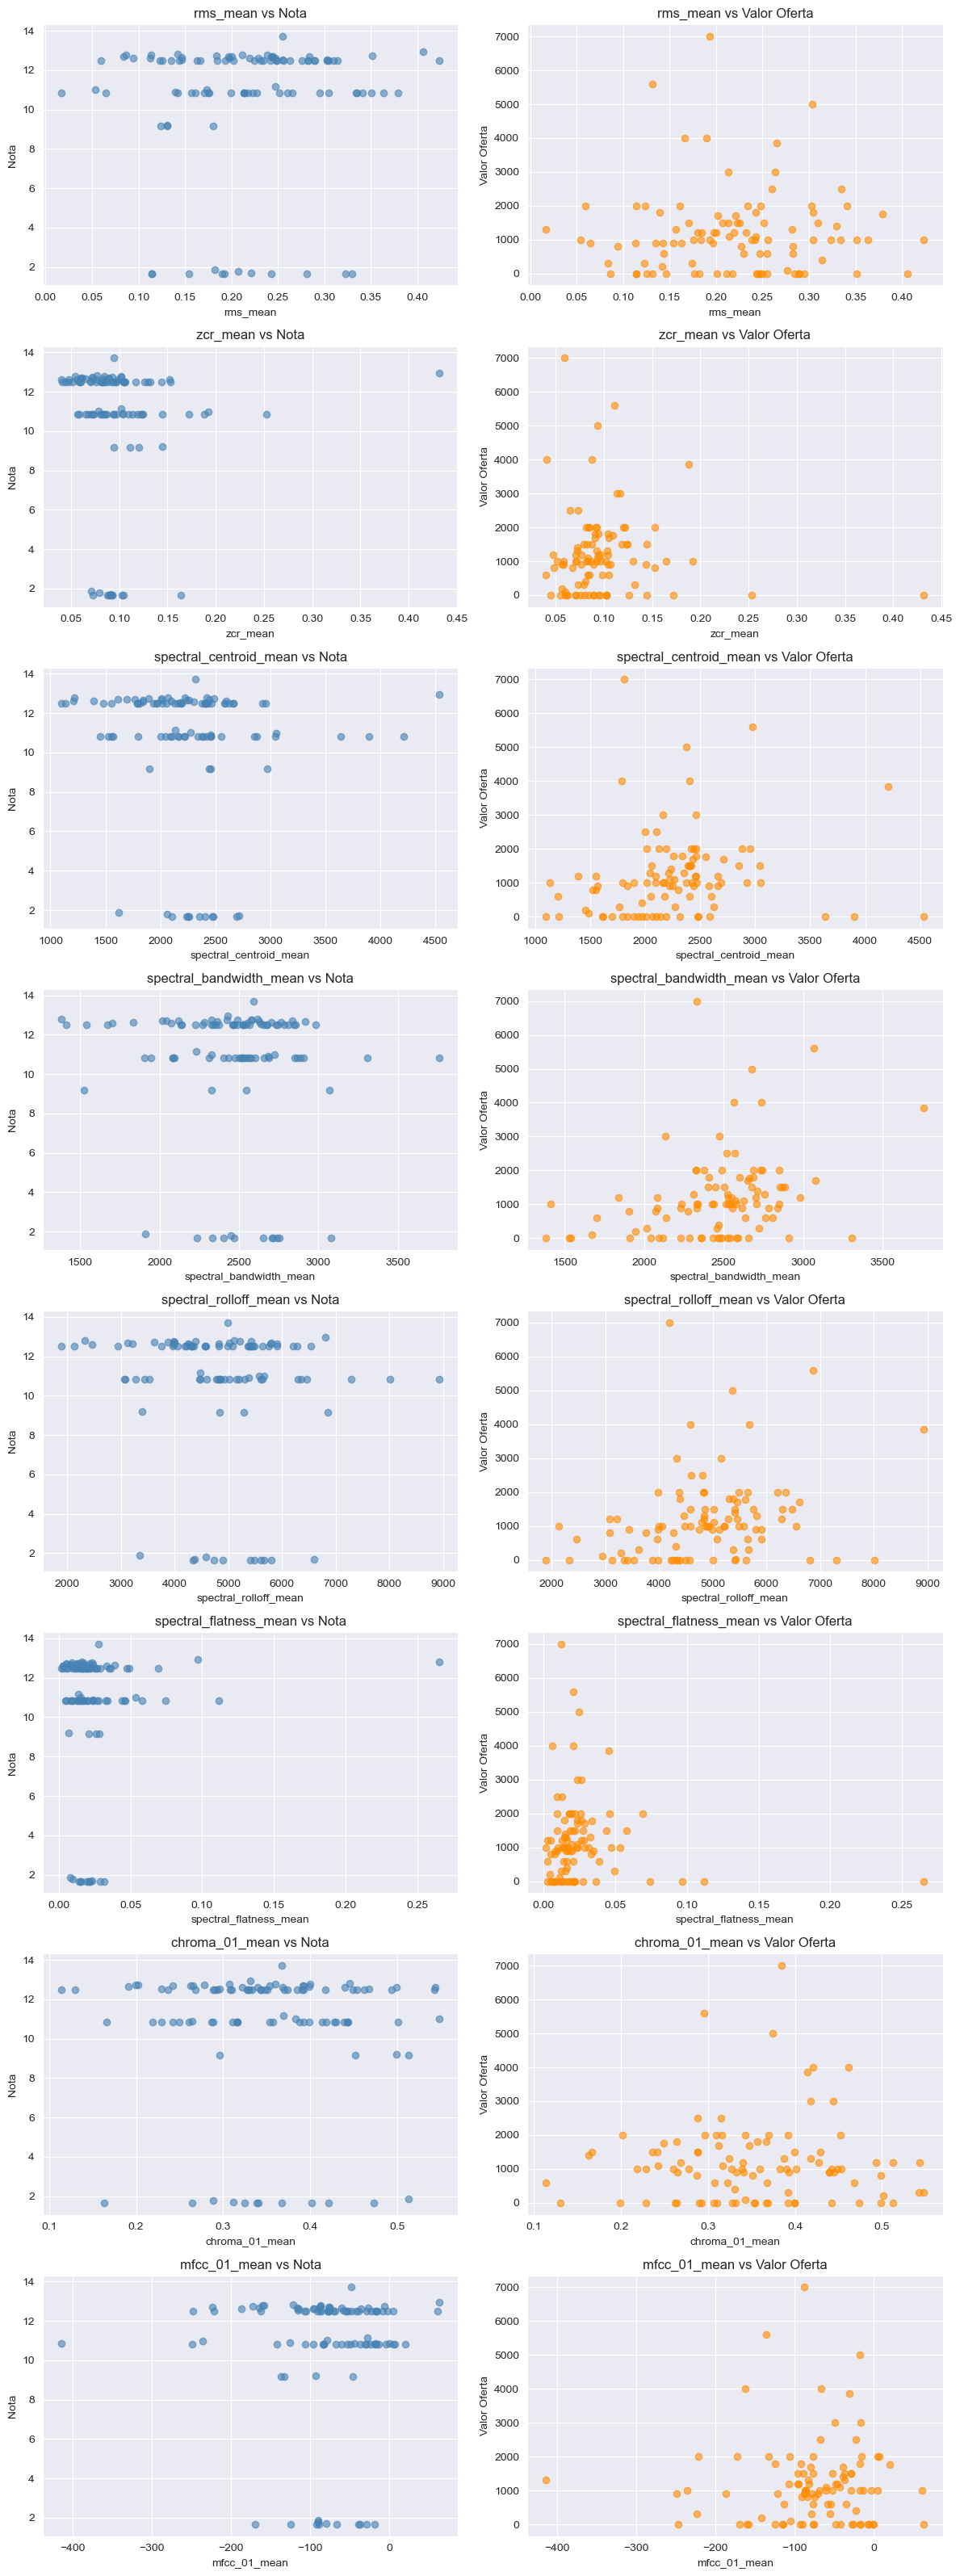

In [58]:
cols_avaliar_scatter = ['rms_mean','zcr_mean','spectral_centroid_mean','spectral_bandwidth_mean','spectral_rolloff_mean','spectral_flatness_mean',
                        'chroma_01_mean','mfcc_01_mean']
n_cols = 2  # dois gráficos por linha
n_rows = len(cols_avaliar_scatter)  # uma linha por variável
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))

for i, col in enumerate(cols_avaliar_scatter):
    # Scatter com nota
    axes[i,0].scatter(df[col], df['nota'], alpha=0.6, color='steelblue')
    axes[i,0].set_xlabel(col)
    axes[i,0].set_ylabel('Nota')
    axes[i,0].set_title(f'{col} vs Nota')

    # Scatter com valor_oferta
    axes[i,1].scatter(df[col], df['valor_oferta'], alpha=0.6, color='darkorange')
    axes[i,1].set_xlabel(col)
    axes[i,1].set_ylabel('Valor Oferta')
    axes[i,1].set_title(f'{col} vs Valor Oferta')

plt.tight_layout()
plt.show()



# Conlusoes e Insigths

1.
> `nota` aprenseta uma assimetria esquerda com uma baixa variancia. isso nos indica o modelo teria dificuldade em diferenciar oque seria um nota boa de uma nota ruim.
> Uma sugestao seria transformar em classes de `baixo` , `media` e `bom`.

2.
> `valor_oferta` apresenta uma distribuicao mais pareceido com uma normal, com valor da media e mediana bem proximos. Isso faz com que os outliers influenciam muito no modelo.
> Uma sugestao é tratar os outliers antes de fazer o treinamento do modelo.

3.
> as features do audio sao as variaveis mais importantes do dataset para a modelagem. Apensar de analisando as correlacoes entre as variaveis de audio com os alvos `nota` e `valor_oferta` nao apresentarem uma correlacao forte, podemos pensar que será necessario modelos mais complexos para aplicar o treinamento do modelo.




## Seleção de Features

`drop:` apenas identificadores e valores iguais para todo o dataset(sem variancia de valor)
> - artist_key, artist_name, ID_ARTISTA, video_url, video_title, video_channel
> - sample_rate, segment_duration_sec, segment_start_sec, formacao, video_duration_sec

`numericas:` variaveis de audio
> - tempo_bpm (ritmo)
>  - rms_mean, rms_std (energia)
> - zcr_mean, zcr_std (textura sonora)
> - pectral_centroid_mean/std, spectral_bandwidth_mean/std, spectral_rolloff_mean/std, spectral_flatness_mean/std (espectro)
> - onset_strength_mean/std (percussividade)
>  - mfcc_01_mean a mfcc_13_mean (timbre)
>  - chroma_01_mean a chroma_12_mean (harmonia)

`categoricas:`  categorias para identificao
> - estilo
> - nota (possibilidade de ser transformada em categorica)

`alvos:` variaveis de alvo do modelo
> - `nota` usado para poder avaliar a banda e fazer recomendacoes de melhores bandas
> - `valor_oferta` usado para saber os preco das bandas e poder ranquear bandas por preco juntamente com a qualidade (nota)
> - `estilo` usado para poder identificar bandas com gostos e estilos parecidos



## Conclusão
> As variaveis ALVO foram descritas de como elas podem serem usadas para poder encontrar bandas com base em qualidade(nota), preco(valor_oferta) e estilo da banda(estilo). O objetivo é poder com essas variaveis identificar bandas com um estilo parecido com oque procura, e ranquear elas pela nota e custo. Apesar dessa ser a ideia inicial da modelagem, nao sei ao certo como isso vai ser possivel.

> Com a analise Inicial dos dados, nao foi encontrado uma relaçao linear nas variaveis, oque sugere que vamos ter que partir para modelos mais complexos. Pela natureza do problema que queremos resolver, que é a identificação de bandas com estilo parecido, isso sugere modelos capazes de fazer classificação e clusterização.